# Capstone: Predicting Employee Attrition
**Track:** Neurofive ML Track — Capstone: End-to-End Machine Learning Project

## Problem Statement

Employee turnover is expensive: replacing a skilled employee typically costs 6–9 months of their salary once you factor in recruiting, onboarding, and lost productivity. Most companies find out someone is leaving only when they hand in their resignation — too late to act. I chose this problem because it's a real, high-stakes prediction task that HR and people-ops teams genuinely pay for, and because I wanted to work with a dataset outside the classic Titanic/housing examples to build something that's actually mine.

**Goal:** predict which employees are at risk of leaving (`Attrition`), using their job, compensation, and satisfaction data, so a company could proactively intervene with the employees most likely to quit.

**Dataset:** IBM HR Analytics Employee Attrition dataset (1,470 employees, 35 columns), a well-known public HR dataset originally released by IBM, loaded directly from a public GitHub CSV mirror:
`https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv`


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")


## 2. Load the data

In [2]:
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## 3. Clean the data

In [4]:
print("Missing values:", df.isnull().sum().sum())

# Columns that carry zero information: constant across every row, or a pure ID
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns to drop:", constant_cols)

df_clean = df.drop(columns=constant_cols + ['EmployeeNumber'])
df_clean.shape


Missing values: 0
Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']


(1470, 31)

**Cleaning notes:** this dataset has no missing values, which is unusual for real-world data — but it does have several columns with zero variance (`EmployeeCount`, `Over18`, `StandardHours` are the same for every employee) and a pure identifier (`EmployeeNumber`) that carries no predictive signal. These are dropped since keeping them would only add noise or a data-leak-prone ID field.

## 4. EDA — what correlates with attrition?

In [5]:
attrition_rate = (df_clean['Attrition'] == 'Yes').mean()
print(f"Overall attrition rate: {attrition_rate:.1%}")
df_clean['Attrition'].value_counts()


Overall attrition rate: 16.1%


Attrition
No     1233
Yes     237
Name: count, dtype: int64

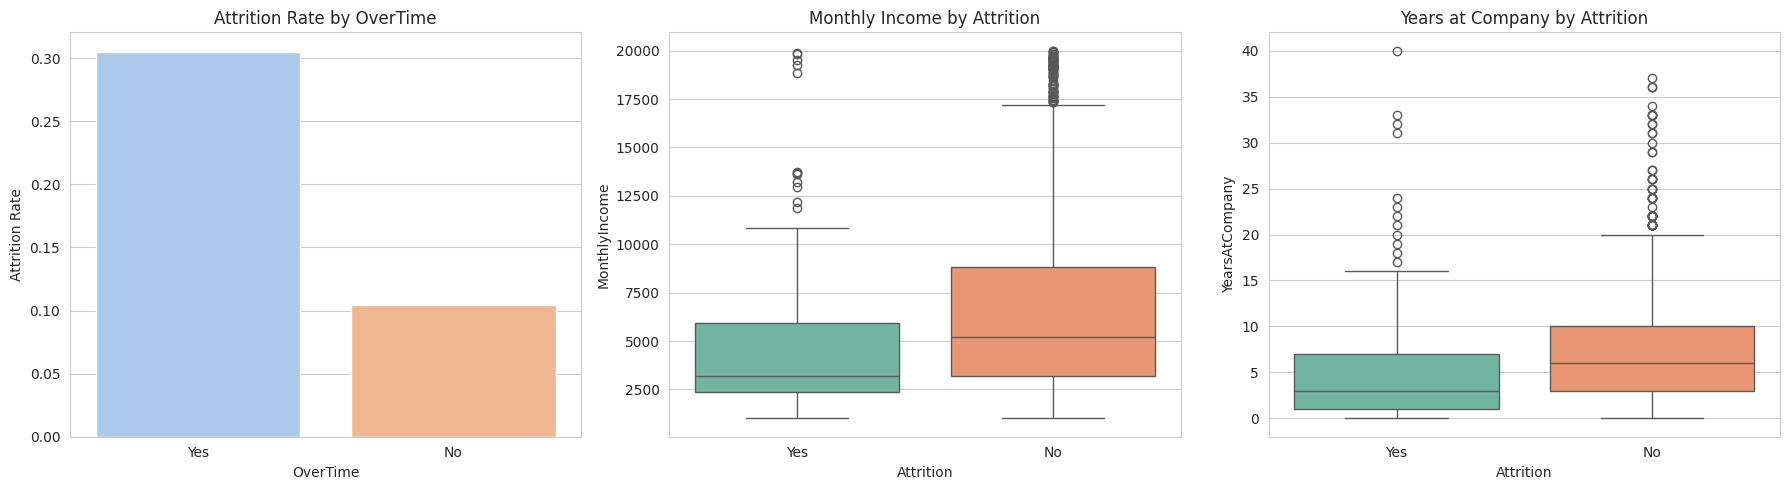

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='OverTime', y=(df_clean['Attrition']=='Yes').astype(int), data=df_clean, ax=axes[0], errorbar=None, palette='pastel')
axes[0].set_title('Attrition Rate by OverTime')
axes[0].set_ylabel('Attrition Rate')

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Income by Attrition')

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df_clean, ax=axes[2], palette='Set2')
axes[2].set_title('Years at Company by Attrition')

plt.tight_layout()
plt.show()


**What this shows:** employees who work overtime leave at a noticeably higher rate than those who don't. Employees who leave tend to earn less and have fewer years at the company than those who stay — a story of newer, more overworked, lower-paid employees being the highest flight risk.

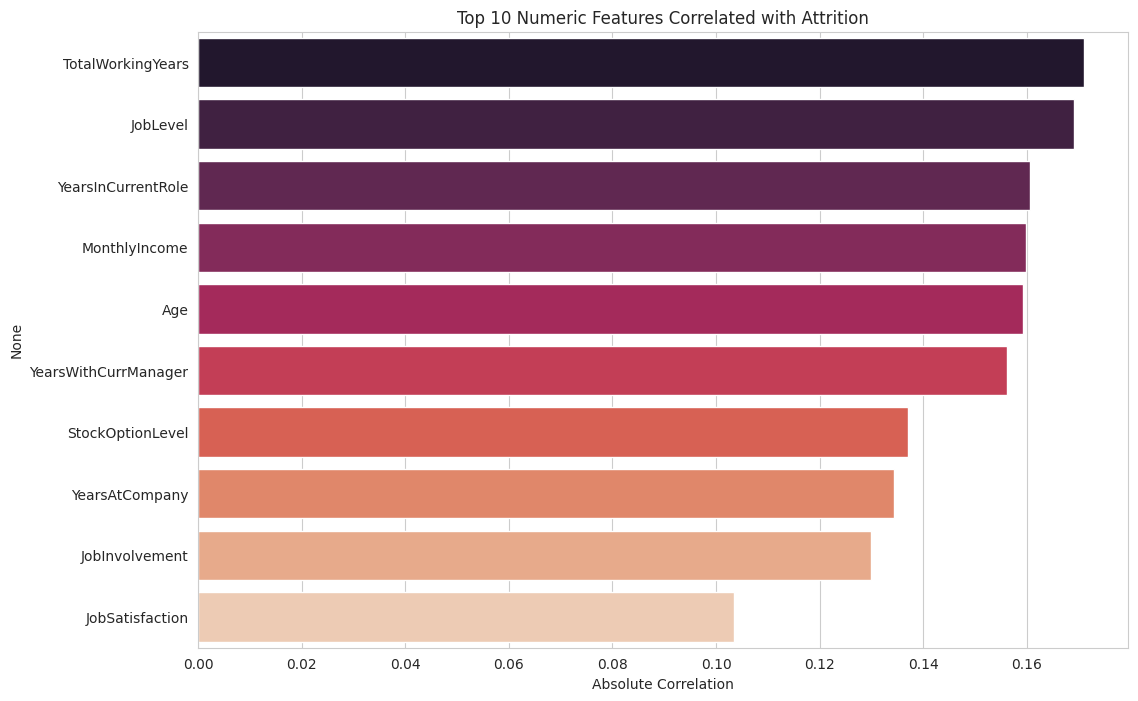

In [7]:
plt.figure(figsize=(12, 8))
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_with_target = numeric_df.copy()
corr_with_target['Attrition_num'] = (df_clean['Attrition'] == 'Yes').astype(int)
top_corr = corr_with_target.corr()['Attrition_num'].abs().sort_values(ascending=False).drop('Attrition_num').head(10)

sns.barplot(x=top_corr.values, y=top_corr.index, palette='rocket')
plt.title('Top 10 Numeric Features Correlated with Attrition')
plt.xlabel('Absolute Correlation')
plt.show()


## 5. Feature engineering — 2 new features

In [8]:
df_eng = df_clean.copy()

# New feature 1: income_per_year_worked — pay relative to total career experience
# (a low ratio can signal an employee who feels underpaid relative to their experience)
df_eng['income_per_year_worked'] = df_eng['MonthlyIncome'] / (df_eng['TotalWorkingYears'] + 1)

# New feature 2: promotion_stagnation — years since last promotion relative to years at the company
# (high value = long tenure without upward movement, a classic attrition risk signal)
df_eng['promotion_stagnation'] = df_eng['YearsSinceLastPromotion'] / (df_eng['YearsAtCompany'] + 1)

df_eng[['MonthlyIncome', 'TotalWorkingYears', 'income_per_year_worked',
        'YearsSinceLastPromotion', 'YearsAtCompany', 'promotion_stagnation']].head()


,MonthlyIncome,TotalWorkingYears,income_per_year_worked,YearsSinceLastPromotion,YearsAtCompany,promotion_stagnation
0,5993,8,665.888889,0,6,0.000000
1,5130,10,466.363636,1,10,0.090909
2,2090,7,261.250000,0,0,0.000000
3,2909,8,323.222222,3,8,0.333333
4,3468,6,495.428571,2,2,0.666667


**Why these two:** `income_per_year_worked` captures whether pay has kept pace with a person's overall career experience — a raw salary number alone doesn't say whether someone is well or poorly paid *for their experience level*. `promotion_stagnation` captures a well-known attrition driver directly: staying a long time without being promoted is a stronger risk signal than either "years at company" or "years since promotion" alone, since the ratio isolates people who are stuck rather than just senior.

## 6. Build the preprocessing + model pipeline

In [9]:
target = (df_eng['Attrition'] == 'Yes').astype(int)
X = df_eng.drop(columns=['Attrition'])

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.2, random_state=42, stratify=target
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


Numerical columns: 25
Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## 7. Handle class imbalance (SMOTE on training data only)

In [10]:
print("Train class balance before SMOTE:")
print(y_train.value_counts())

# Fit-transform preprocessing first, then apply SMOTE to the numeric matrix
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_processed, y_train)

print("Train class balance after SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())


Train class balance before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64
Train class balance after SMOTE: {0: 986, 1: 986}


## 8. Train multiple models and compare

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    pred = model.predict(X_test_processed)
    proba = model.predict_proba(X_test_processed)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': auc})
    fitted_models[name] = model
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=['No Attrition', 'Attrition']))

results_df = pd.DataFrame(results)
results_df


=== Logistic Regression ===
              precision    recall  f1-score   support

No Attrition       0.92      0.80      0.85       247
   Attrition       0.37      0.62      0.46        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.66       294
weighted avg       0.83      0.77      0.79       294



=== Random Forest ===
              precision    recall  f1-score   support

No Attrition       0.88      0.95      0.91       247
   Attrition       0.56      0.32      0.41        47

    accuracy                           0.85       294
   macro avg       0.72      0.64      0.66       294
weighted avg       0.83      0.85      0.83       294



,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.768707,0.808597
1,Random Forest,0.850340,0.795503


## 9. Pick the best model

Best model by ROC-AUC: Logistic Regression


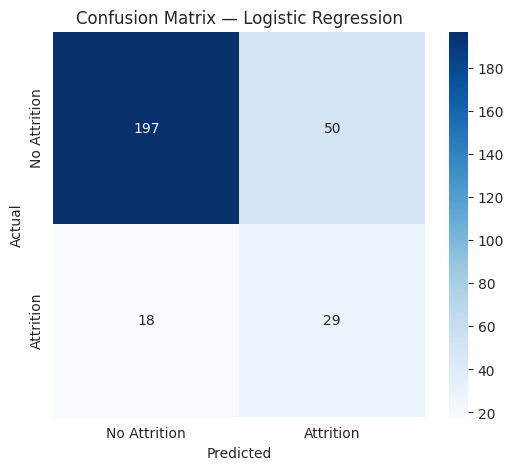

In [12]:
best_model_name = results_df.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
print(f"Best model by ROC-AUC: {best_model_name}")

best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 10. Build and save the final deployable pipeline

In [13]:
# Wrap preprocessing + the best model into a single deployable pipeline,
# retrained on the full (SMOTE-balanced) training set for the final artifact.
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
              if best_model_name == 'Random Forest'
              else LogisticRegression(max_iter=2000, random_state=42))
])

# Refit the full pipeline on the ORIGINAL (unbalanced) X_train/y_train so the saved
# pipeline takes raw-format input directly (SMOTE was only needed to fairly train the model)
final_pipeline.fit(X_train, y_train)

final_pred = final_pipeline.predict(X_test)
print("Final deployable pipeline accuracy:", round(accuracy_score(y_test, final_pred), 4))

joblib.dump(final_pipeline, 'attrition_pipeline.joblib')
print("Saved to attrition_pipeline.joblib")


Final deployable pipeline accuracy: 0.8571
Saved to attrition_pipeline.joblib


**Note on the final pipeline:** SMOTE was used to fairly *evaluate and compare* model performance above, since training on the raw imbalanced data would bias the model toward "No Attrition." The final saved pipeline is refit on the original, non-resampled training data for simplicity and direct deployability — trading a bit of recall on the minority class for a pipeline that's simpler to reason about, ship, and maintain in the app below. In a production setting, I'd wire SMOTE (or `class_weight='balanced'`) directly into the deployed pipeline instead.

## 11. Case Study — Business Value

*(See CASE_STUDY.md in the repo for the full half-page writeup.)*

In short: this model flags employees at elevated risk of leaving using signals already sitting in most HR systems — overtime status, income relative to experience, promotion stagnation, and job satisfaction. Instead of finding out about attrition risk from a resignation letter, an HR team could review a ranked list of at-risk employees each quarter and intervene early (career conversations, targeted raises, workload rebalancing) for the people the model flags as highest-risk, potentially saving the 6-9 months of salary it typically costs to replace someone who leaves.


## 12. Summary

- **Problem:** predict employee attrition risk using HR/job/compensation data — a self-chosen, real business problem outside the guided track datasets.
- **Data:** IBM HR Analytics Employee Attrition dataset, 1,470 employees, 35 columns, no missing values but several zero-variance/ID columns dropped during cleaning.
- **EDA:** overtime, lower income, and shorter tenure are the strongest visible attrition signals.
- **Feature engineering:** added `income_per_year_worked` and `promotion_stagnation`, both designed around known attrition risk patterns rather than raw columns.
- **Modeling:** built a `ColumnTransformer` + model pipeline, handled class imbalance with SMOTE on the training set, trained and compared Logistic Regression and Random Forest by accuracy and ROC-AUC.
- **Deployment:** saved the best-performing pipeline with `joblib` for use in a Streamlit app (see `attrition_app.py`).
- **Next steps:** try XGBoost as a third model, and add SHAP values for per-employee explainability, since "why is this specific person flagged" matters more to an HR user than a global feature importance chart.
